Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# Column names as per UCI Adult Dataset documentation
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Load directly from UCI repository
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

train_df = pd.read_csv(train_url, header=None, names=columns,
                        sep=',', skipinitialspace=True, na_values='?')
test_df = pd.read_csv(test_url, header=None, names=columns,
                       sep=',', skipinitialspace=True, na_values='?', skiprows=1)

# Clean target column in test set (it has trailing periods)
test_df['income'] = test_df['income'].str.replace('.', '', regex=False)

# Combine for unified cleaning/feature engineering, split again later
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Task 1 — Dataset Understanding (10 Marks)

TASK 1: DATASET UNDERSTANDING

Shape of dataset: (48842, 15)

Column Data Types:
 age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

First 5 rows:
    age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    

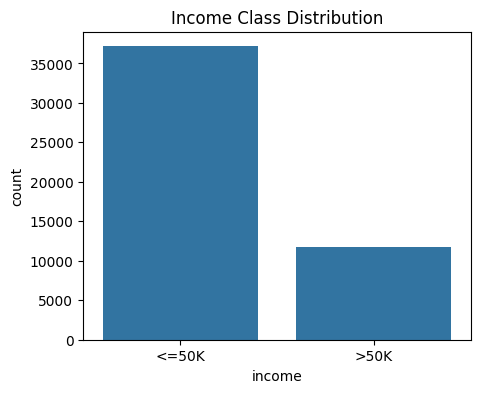

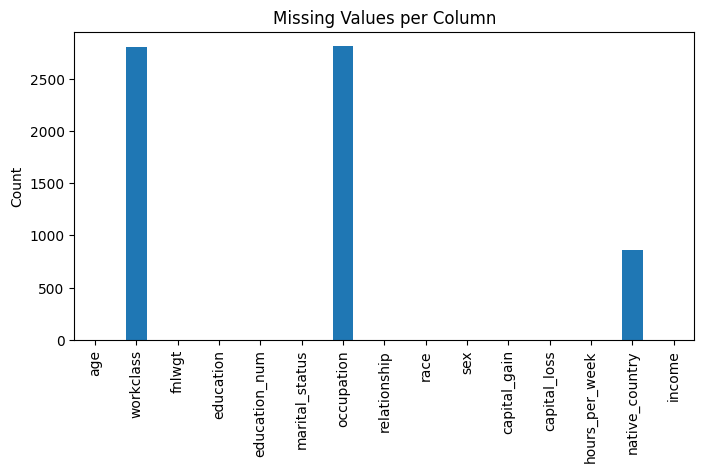

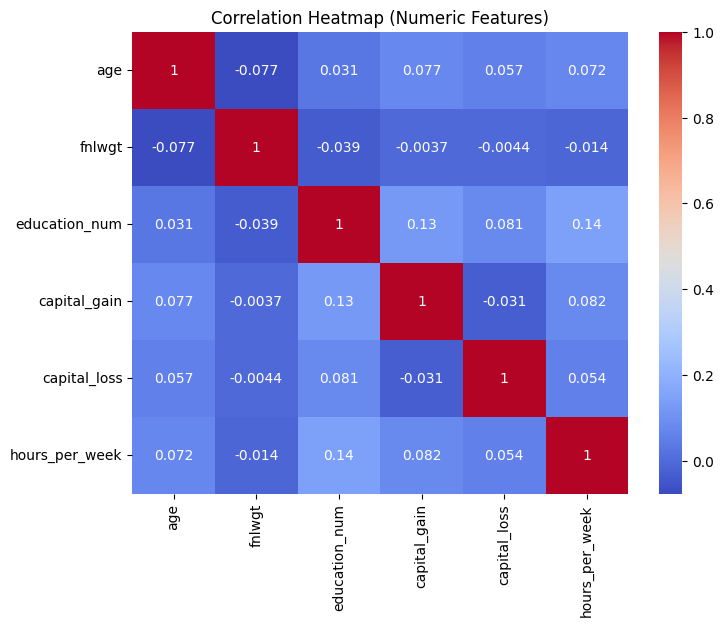

In [ ]:
print("="*60)
print("TASK 1: DATASET UNDERSTANDING")
print("="*60)

print("\nShape of dataset:", df.shape)
print("\nColumn Data Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nStatistical Summary (numerical):\n", df.describe())
print("\nMissing Values per Column:\n", df.isnull().sum())
print("\nTarget Variable Distribution:\n", df['income'].value_counts())

# Visualize target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='income', data=df)
plt.title('Income Class Distribution')
plt.show()

# Visualize missing values
plt.figure(figsize=(8,4))
df.isnull().sum().plot(kind='bar')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

Task 2 — Data Cleaning (20 Marks)

TASK 2: DATA CLEANING
Missing values before cleaning:
 age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
dtype: int64

Missing values after cleaning:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Duplicate rows before: 53
Duplicate rows after: 0
Outliers in age: 215
Outliers in hours_per_week: 13486
Outliers in capital_gain: 4035
Outliers in capital_loss: 2282


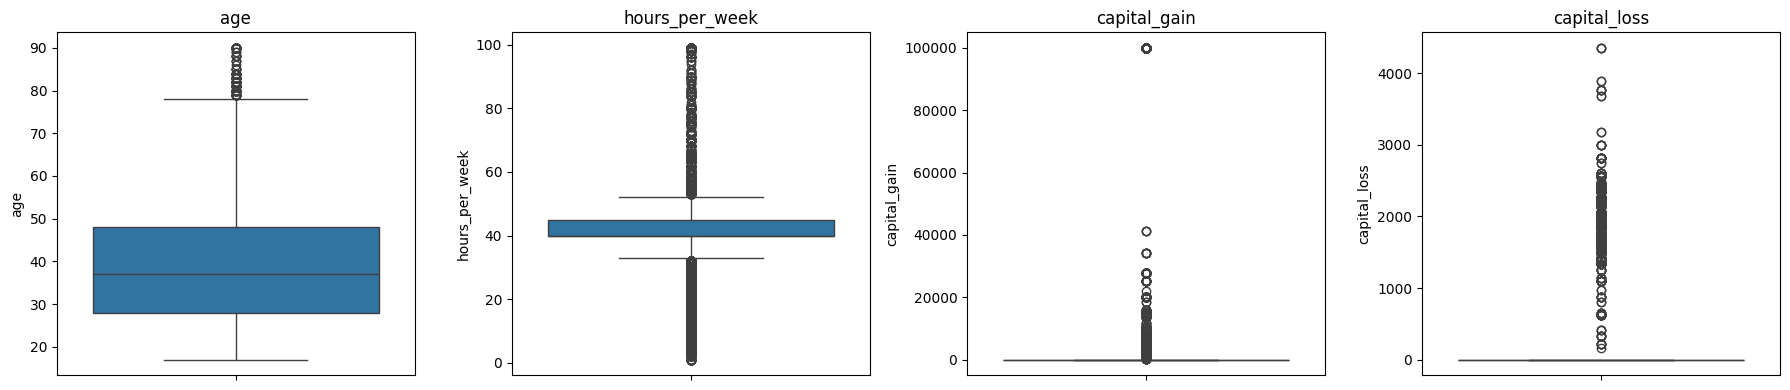


Final dataset shape after cleaning: (48789, 15)


In [ ]:
print("="*60)
print("TASK 2: DATA CLEANING")
print("="*60)

# Check missing values (marked as '?' -> already converted to NaN during load)
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill missing categorical values with mode
for col in ['workclass', 'occupation', 'native_country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())

# Remove duplicate rows
print("\nDuplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())

# Strip whitespace from string columns (extra safety)
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

# Outlier detection using IQR (example: age, hours_per_week)
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return data[(data[col] < lower) | (data[col] > upper)]

for col in ['age', 'hours_per_week', 'capital_gain', 'capital_loss']:
    outliers = detect_outliers_iqr(df, col)
    print(f"Outliers in {col}: {len(outliers)}")

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, col in zip(axes, ['age', 'hours_per_week', 'capital_gain', 'capital_loss']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Cap extreme outliers in hours_per_week (cleaning, not full removal to avoid losing info)
df['hours_per_week'] = df['hours_per_week'].clip(lower=1, upper=99)

print("\nFinal dataset shape after cleaning:", df.shape)

Task 3 — Feature Engineering (15 Marks)

In [ ]:
print("="*60)
print("TASK 3: FEATURE ENGINEERING")
print("="*60)

# Drop fnlwgt (sampling weight, not predictive of individual income)
df.drop(columns=['fnlwgt'], inplace=True)

# Create new feature: capital_net = capital_gain - capital_loss
df['capital_net'] = df['capital_gain'] - df['capital_loss']

# Create age bins (categorical bucketing)
df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,100],
                          labels=['Young','Adult','Middle_Aged','Senior'])

# Encode target variable
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Identify categorical columns for encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols += ['age_group']
print("\nCategorical columns to encode:", categorical_cols)

# Label Encoding for categorical features
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("\nDataset after encoding:\n", df.head())

# Feature/Target split
X = df.drop(columns=['income'])
y = df['income']

# Scale numerical features
scaler = StandardScaler()
num_cols = ['age', 'education_num', 'capital_gain', 'capital_loss',
            'hours_per_week', 'capital_net']
X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nFinal feature set shape:", X.shape)
print("Target distribution:\n", y.value_counts())

TASK 3: FEATURE ENGINEERING

Categorical columns to encode: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'age_group']

Dataset after encoding:
    age  workclass  education  education_num  marital_status  occupation  \
0   39          6          9             13               4           0   
1   50          5          9             13               2           3   
2   38          3         11              9               0           5   
3   53          3          1              7               2           5   
4   28          3          9             13               2           9   

   relationship  race  sex  capital_gain  capital_loss  hours_per_week  \
0             1     4    1          2174             0              40   
1             0     4    1             0             0              13   
2             1     4    1             0             0              40   
3             0     2    1             0      

Task 4 — Model Building (30 Marks)

In [ ]:
print("="*60)
print("TASK 4: MODEL BUILDING")
print("="*60)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42)
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

TASK 4: MODEL BUILDING
Train shape: (39031, 15)  Test shape: (9758, 15)

Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training KNN...
KNN trained successfully.

Training SVM...
SVM trained successfully.


Task 5 — Performance Evaluation (15 Marks)

TASK 5: PERFORMANCE EVALUATION

--- Logistic Regression ---
Confusion Matrix:
 [[7022  400]
 [1228 1108]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      7422
           1       0.73      0.47      0.58      2336

    accuracy                           0.83      9758
   macro avg       0.79      0.71      0.74      9758
weighted avg       0.82      0.83      0.82      9758


--- Decision Tree ---
Confusion Matrix:
 [[6590  832]
 [ 873 1463]]
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      7422
           1       0.64      0.63      0.63      2336

    accuracy                           0.83      9758
   macro avg       0.76      0.76      0.76      9758
weighted avg       0.82      0.83      0.82      9758


--- Random Forest ---
Confusion Matrix:
 [[6838  584]
 [ 812 1524]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.91    

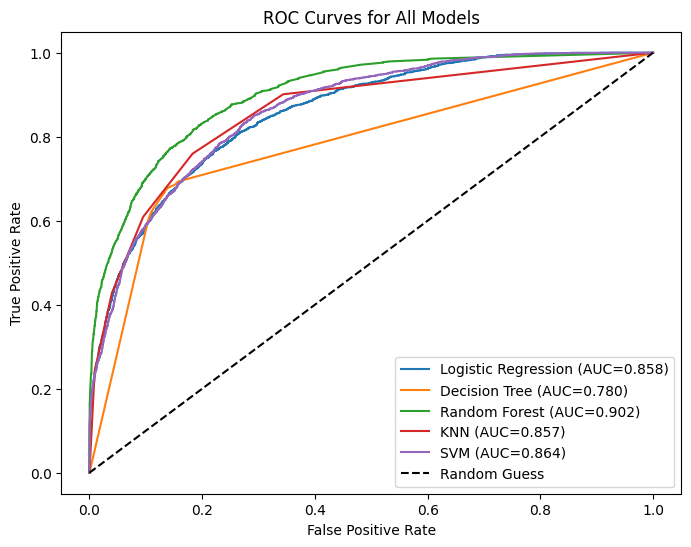


Final Performance Comparison Table:

          Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8332     0.7347  0.4743    0.5765   0.8582
      Decision Tree    0.8253     0.6375  0.6263    0.6318   0.7799
      Random Forest    0.8569     0.7230  0.6524    0.6859   0.9023
                KNN    0.8340     0.6681  0.6092    0.6373   0.8575
                SVM    0.8132     0.8218  0.2804    0.4181   0.8636


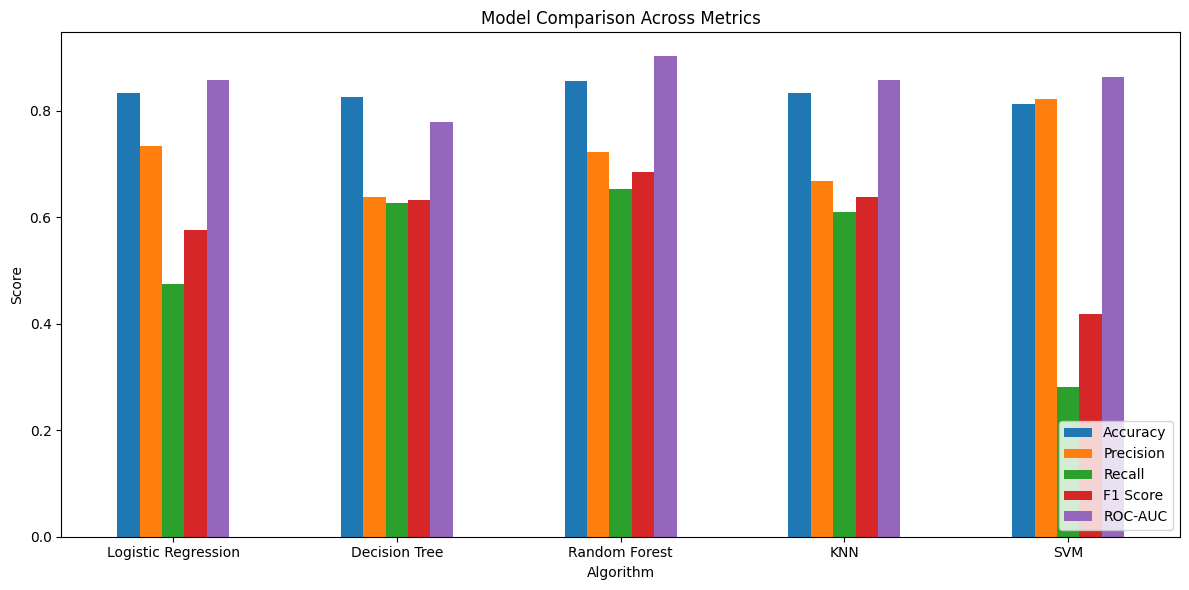

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8332,0.7347,0.4743,0.5765,0.8582
1,Decision Tree,0.8253,0.6375,0.6263,0.6318,0.7799
2,Random Forest,0.8569,0.7230,0.6524,0.6859,0.9023
3,KNN,0.8340,0.6681,0.6092,0.6373,0.8575
4,SVM,0.8132,0.8218,0.2804,0.4181,0.8636


In [ ]:
print("="*60)
print("TASK 5: PERFORMANCE EVALUATION")
print("="*60)

results = []

plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Algorithm': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_test, y_pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.show()

# Final results table (matches the table required in the assignment)
results_df = pd.DataFrame(results)
results_df = results_df[['Algorithm','Accuracy','Precision','Recall','F1 Score','ROC-AUC']]
print("\nFinal Performance Comparison Table:\n")
print(results_df.to_string(index=False))

# Bar chart comparison
results_df.set_index('Algorithm')[['Accuracy','Precision','Recall','F1 Score','ROC-AUC']].plot(
    kind='bar', figsize=(12,6)
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

results_df